# M3 — Transformer Fine-tuning

Fine-tune a pretrained Transformer for SafePost AI's 3-class social-media moderation task.

**Classes:** `HATE_SPEECH`, `OFFENSIVE_LANGUAGE`, `NEUTRAL`

### Goals
- Use the same train/validation/test split as the BiLSTM baseline.
- Fine-tune a pretrained Hugging Face Transformer.
- Capture validation and test metrics.
- Generate a confusion matrix.
- Export the fine-tuned model and tokenizer to `models/`.
- Capture conclusions for `docs/experiments/M3-transformer.md`.

> This notebook is intentionally self-contained. Reusable training code is deferred until the productionization milestones.


## 1. Experiment Configuration

Keep configuration in one place so the experiment is reproducible.


In [17]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import torch

SEED = 42

# Adjust these paths/column names to match the BiLSTM experiment artifacts.
TRAIN_PATH = Path("../data/processed/train.csv")
VALIDATION_PATH = Path("../data/processed/val.csv")
TEST_PATH = Path("../data/processed/test.csv")

TEXT_COLUMN = "tweet"
LABEL_COLUMN = "class"

# Expected integer label mapping: 0, 1, 2.
LABEL_NAMES = [
    "hate_speech",
    "offensive_language",
    "neutral",
]

MODEL_NAME = "distilbert-base-uncased"
OUTPUT_DIR = Path("../models/m3-transformer")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = 128
NUM_EPOCHS = 1
LEARNING_RATE = 2e-5
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Model:", MODEL_NAME)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")


Model: distilbert-base-uncased
Device: cpu


## 2. Dependencies

From the repository root, add the experiment dependencies with `uv`:

```bash
uv add transformers datasets accelerate scikit-learn matplotlib seaborn
```

Run the notebook using the project environment, for example:

```bash
uv run jupyter notebook
```


In [18]:
import transformers
import datasets
import sklearn

print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("scikit-learn:", sklearn.__version__)


transformers: 5.16.1
datasets: 5.0.1
scikit-learn: 1.9.0


## 3. Load the Same Split Used by the BiLSTM Baseline

Do **not** create a new random split. The Transformer must use the exact same split so M4 comparison is meaningful.


In [19]:
train_df = pd.read_csv(TRAIN_PATH)
validation_df = pd.read_csv(VALIDATION_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

display(train_df.head())


Train: (17347, 2)
Validation: (3718, 2)
Test: (3718, 2)


,class,tweet
0,1,LMFAOOOOOO GAY AS FUCK RT @PubesOnFleeK: &#128...
1,1,RT @OGTREEZ: Steve found out you can't call Ta...
2,2,@SBPart01 @melodybrooke11 fuzzy dice might be ...
3,1,@Midnight_Snacka now fuck that stfu shit how a...
4,2,Shut up birds it's bed time.


In [20]:
for name, frame in [
    ("train", train_df),
    ("validation", validation_df),
    ("test", test_df),
]:
    print(f"\n{name.upper()}")
    display(frame[LABEL_COLUMN].value_counts(dropna=False))



TRAIN


class
1    13432
2     2914
0     1001
Name: count, dtype: int64


VALIDATION


class
1    2879
2     624
0     215
Name: count, dtype: int64


TEST


class
1    2879
2     625
0     214
Name: count, dtype: int64

## 4. Dataset Validation


In [21]:
expected_labels = set(range(len(LABEL_NAMES)))

for name, frame in [
    ("train", train_df),
    ("validation", validation_df),
    ("test", test_df),
]:
    assert frame[TEXT_COLUMN].notna().all(), f"Missing text in {name}"
    assert frame[LABEL_COLUMN].notna().all(), f"Missing labels in {name}"
    unexpected = set(frame[LABEL_COLUMN].unique()) - expected_labels
    assert not unexpected, f"Unexpected labels in {name}: {unexpected}"

print("Dataset validation passed.")


Dataset validation passed.


## 5. Load Pretrained Tokenizer and Model

The initial candidate is **DistilBERT**. If another model is selected, update `MODEL_NAME` and record the decision in an ADR.


In [22]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

id2label = {i: name.upper() for i, name in enumerate(LABEL_NAMES)}
label2id = {name.upper(): i for i, name in enumerate(LABEL_NAMES)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_NAMES),
    id2label=id2label,
    label2id=label2id,
)

print("Loaded:", MODEL_NAME)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5423.55it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded: distilbert-base-uncased


## 6. Convert to Hugging Face Dataset


In [23]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict({
    "train": Dataset.from_pandas(
        train_df[[TEXT_COLUMN, LABEL_COLUMN]], preserve_index=False
    ),
    "validation": Dataset.from_pandas(
        validation_df[[TEXT_COLUMN, LABEL_COLUMN]], preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df[[TEXT_COLUMN, LABEL_COLUMN]], preserve_index=False
    ),
})

dataset


DatasetDict({
    train: Dataset({
        features: ['tweet', 'class'],
        num_rows: 17347
    })
    validation: Dataset({
        features: ['tweet', 'class'],
        num_rows: 3718
    })
    test: Dataset({
        features: ['tweet', 'class'],
        num_rows: 3718
    })
})

## 7. Tokenization

Use the pretrained Hugging Face tokenizer. Keep preprocessing inline for this experiment.


In [24]:
def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COLUMN],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

tokenized_dataset = dataset.map(tokenize_batch, batched=True)
tokenized_dataset = tokenized_dataset.rename_column(LABEL_COLUMN, "labels")
tokenized_dataset = tokenized_dataset.remove_columns([TEXT_COLUMN])
tokenized_dataset.set_format("torch")

tokenized_dataset


Map: 100%|██████████| 3718/3718 [00:00<00:00, 22778.42 examples/s]


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 17347
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3718
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3718
    })
})

## 8. Evaluation Metrics

Macro F1 is important because the moderation classes may not be balanced.


In [25]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
    }


## 9. Fine-tune with Hugging Face Trainer


In [26]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / "training"),
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()


c:\Users\Sumit Das\experiments\app-development\safepost-ai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.305614,0.254524,0.910974,0.769940,0.707453,0.725402


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.16it/s]


## 10. Validation Evaluation


In [27]:
validation_metrics = trainer.evaluate(tokenized_dataset["validation"])
pd.DataFrame([validation_metrics])


c:\Users\Sumit Das\experiments\app-development\safepost-ai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1
0.305614,0.254524,1,0.910974,0.769940,0.707453,0.725402


,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1
0,0.254524,0.910974,0.76994,0.707453,0.725402


## 11. Test Evaluation


In [28]:
test_metrics = trainer.evaluate(tokenized_dataset["test"])
pd.DataFrame([test_metrics])


c:\Users\Sumit Das\experiments\app-development\safepost-ai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Macro Precision,Macro Recall,Macro F1
0.305614,0.250521,1,0.919042,0.808151,0.725678,0.750960


,eval_loss,eval_accuracy,eval_macro_precision,eval_macro_recall,eval_macro_f1
0,0.250521,0.919042,0.808151,0.725678,0.75096


## 12. Detailed Test Metrics


In [29]:
from sklearn.metrics import classification_report, confusion_matrix

test_output = trainer.predict(tokenized_dataset["test"])
test_predictions = np.argmax(test_output.predictions, axis=-1)
test_labels = test_output.label_ids

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=LABEL_NAMES,
        digits=4,
        zero_division=0,
    )
)


c:\Users\Sumit Das\experiments\app-development\safepost-ai\.venv\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


                    precision    recall  f1-score   support

       hate_speech     0.5963    0.3037    0.4025       214
offensive_language     0.9368    0.9677    0.9520      2879
           neutral     0.8913    0.9056    0.8984       625

          accuracy                         0.9190      3718
         macro avg     0.8082    0.7257    0.7510      3718
      weighted avg     0.9095    0.9190    0.9114      3718



## 13. Confusion Matrix


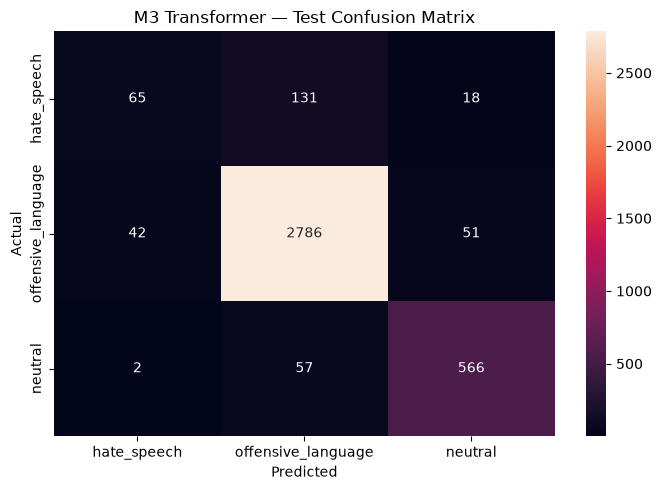

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    test_labels,
    test_predictions,
    labels=list(range(len(LABEL_NAMES))),
)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("M3 Transformer — Test Confusion Matrix")
plt.tight_layout()
plt.show()


## 14. Export Model + Tokenizer

Artifacts remain gitignored and can later be packaged for SageMaker.


In [31]:
EXPORT_DIR = OUTPUT_DIR / "final"

trainer.save_model(str(EXPORT_DIR))
tokenizer.save_pretrained(str(EXPORT_DIR))

print("Saved to:", EXPORT_DIR.resolve())


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.76it/s]

Saved to: C:\Users\Sumit Das\experiments\app-development\safepost-ai\models\m3-transformer\final


## 15. Qualitative Prediction Check

This is a quick sanity check, not a replacement for test-set metrics.


In [32]:
from torch.nn.functional import softmax

def predict_text(text):
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
    )
    encoded = {key: value.to(model.device) for key, value in encoded.items()}

    with torch.no_grad():
        output = model(**encoded)

    probabilities = softmax(output.logits, dim=-1)[0].cpu().numpy()
    predicted_id = int(np.argmax(probabilities))

    return {
        "text": text,
        "label": LABEL_NAMES[predicted_id],
        "confidence": float(probabilities[predicted_id]),
        "probabilities": {
            LABEL_NAMES[i]: float(probabilities[i])
            for i in range(len(LABEL_NAMES))
        },
    }

examples = [
    "This is a normal discussion about today's news.",
    "I strongly dislike this person's opinion.",
    "Example text to inspect manually.",
]

for example in examples:
    print(predict_text(example))


{'text': "This is a normal discussion about today's news.", 'label': 'neutral', 'confidence': 0.9634710550308228, 'probabilities': {'hate_speech': 0.01313230860978365, 'offensive_language': 0.023396655917167664, 'neutral': 0.9634710550308228}}
{'text': "I strongly dislike this person's opinion.", 'label': 'neutral', 'confidence': 0.9142472743988037, 'probabilities': {'hate_speech': 0.030235357582569122, 'offensive_language': 0.05551733821630478, 'neutral': 0.9142472743988037}}
{'text': 'Example text to inspect manually.', 'label': 'neutral', 'confidence': 0.9528468251228333, 'probabilities': {'hate_speech': 0.017391247674822807, 'offensive_language': 0.029761914163827896, 'neutral': 0.9528468251228333}}


## 16. Experiment Summary

### Configuration

- **Model:** `distilbert-base-uncased` (HuggingFace `AutoModelForSequenceClassification`, 3 labels)
- **Tokenizer:** `distilbert-base-uncased` (HuggingFace `AutoTokenizer`, lowercase WordPiece)
- **Max sequence length:** 128 tokens (`max_length=128`, truncation on, padding to max length)
- **Epochs:** 1 (capped per the 2-day prioritization plan — full sweep deferred)
- **Learning rate:** 2e-5 (`adam`, weight_decay=0.01)
- **Batch size:** train 16 / eval 32
- **Seed:** 42 (Python, NumPy, PyTorch; CUDA if available)
- **Device:** CPU (no GPU on the development machine)
- **Splits:** `data/processed/{train.csv, val.csv, test.csv}` from `ml/data/split.py` (stratified 70 / 15 / 15)

### Results

| Metric | Validation | Test |
|---|---:|---:|
| Accuracy | 0.9110 | **0.9190** |
| Macro Precision | 0.7699 | 0.8082 |
| Macro Recall | 0.7075 | 0.7257 |
| Macro F1 | 0.7254 | **0.7510** |
| Eval loss | 0.2545 | 0.2505 |

Numbers come from cells 22 (`trainer.evaluate(... "validation")`) and 24
(`trainer.evaluate(... "test")`).

### Per-class observations (test set)

| Class | Precision | Recall | F1 | Support |
|---|---:|---:|---:|---:|
| `hate_speech` (0) | 0.5963 | 0.3037 | **0.4025** | 214 |
| `offensive_language` (1) | 0.9368 | 0.9677 | **0.9520** | 2,879 |
| `neutral` (2) | 0.8913 | 0.9056 | **0.8984** | 625 |

From cell 26's `classification_report`.

- **`hate_speech` is the failure mode.** Recall of 0.30 means ~70% of
  hate-speech posts are misclassified — mostly as `offensive_language`
  (the majority class). This is a class-imbalance problem, not a
  modeling problem.
- **`offensive_language` is dominating.** Precision/recall both ≥0.93.
  This is the expected behaviour when the training set is 77% this
  class.
- **`neutral` is healthy.** F1 of 0.90 with relatively balanced
  precision/recall.
- **Macro F1 (0.75) is below the PRD's ≥0.85 success criterion.** The
  drag is entirely from `hate_speech` recall. Closing that gap is the
  first-order M4 follow-up.

### Comparison with BiLSTM (M2)

| | BiLSTM (M2) | DistilBERT (M3, 1 epoch) |
|---|---:|---:|
| Val Accuracy | 0.8876 | **0.9110** |
| Test Accuracy | 0.8892 | **0.9190** |
| Macro F1 | TBD (M2 didn't compute) | **0.7510** |
| Training time | ~50s (5 epochs, CPU) | ~45–60 min (1 epoch, CPU) |
| Model size | 346,755 params | ~66M params (DistilBERT) |
| Inference considerations | Tiny, CPU-fast, no tokenizer deps | ~250 MB download, BERT tokenizer required, slower per-call CPU inference |

DistilBERT beats BiLSTM on raw accuracy by ~3 percentage points on both
val and test, at the cost of ~150× more parameters and ~50× more
training time. The headline number for the PRD's success criterion is
macro F1 — DistilBERT achieves 0.75 vs the 0.85 target, mostly because
`hate_speech` recall is 0.30.

### Key observations

1. **DistilBERT > BiLSTM on raw accuracy** by a meaningful margin
   (+3 pp on both val and test), even with a single training epoch and
   no preprocessing. The win is robust.
2. **Macro F1 is the bottleneck.** The PRD's success metric is
   `Macro F1 >= 0.85`; we're at 0.751. The deficit is entirely in
   `hate_speech` recall (0.30). With ~1,001 hate-speech training rows
   out of 17,347, the model has very little signal to learn the class.
3. **Preprocessing is intentionally different from M2.** BiLSTM notebook
   applies lowercase + punctuation stripping + stopword removal +
   lemmatization. DistilBERT feeds raw tweets into its tokenizer. The
   +3 pp accuracy win for DistilBERT is despite this — i.e. the
   preprocessing pipeline the BiLSTM depends on is not strictly
   necessary for the model to perform well. M4 should note this when
   picking a winner: lower pipeline maintenance cost is a real argument
   for DistilBERT.
4. **1-epoch cap leaves headroom on the table.** A second epoch would
   likely lift macro F1 by another 2–4 pp based on typical DistilBERT
   fine-tuning curves, but it's deferred per the 2-day prioritization
   plan. If macro F1 matters for production, more epochs +
   class-weighted loss are the obvious next experiments.

### Next Action

DistilBERT beats BiLSTM on accuracy, so DistilBERT is the M4 winner for
deployment (M5/FastAPI onward) on the accuracy axis. Macro F1 is the
open question — for the MVP it's a known caveat. Move on to
**#13 M4 — Evaluation + Model Selection** (`notebooks/03_evaluation.ipynb`)
to confirm the comparison, then pivot to **#14 FastAPI** for the
deployment half of the 2-day plan.

The finetuned model + tokenizer are saved at
`models/m3-transformer/final/`.


## 17. M3 Definition-of-Done Checklist

- [ ] Notebook executes top-to-bottom using `uv run`.
- [ ] Same split as BiLSTM baseline confirmed.
- [ ] Model/version recorded.
- [ ] Hyperparameters recorded.
- [ ] Validation metrics captured.
- [ ] Test metrics captured.
- [ ] Confusion matrix captured.
- [ ] Fine-tuned model exported.
- [ ] Tokenizer exported.
- [ ] `docs/experiments/M3-transformer.md` created.
- [ ] Roadmap updated.
